### Import Libraries

In [20]:
# Import required libraries for neural networks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")
print("Using scikit-learn MLPClassifier for neural network")

Libraries imported successfully!
Using scikit-learn MLPClassifier for neural network


### Load Iris Dataset (Multi-Class Classification)

In [11]:
# Load iris dataset (multi-class classification, 3 species)
df = pd.read_csv('1) iris.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (150, 5)

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Explore Dataset

In [12]:
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution (Species):")
print(df['species'].value_counts())

print("\nFeature Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Class Distribution (Species):
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Feature Statistics:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.00

### Preprocess Data

In [13]:
# Separate features and target
X = df.drop('species', axis=1)
y = df['species']

# Encode target labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # 0,1,2 for Setosa, Versicolor, Virginica

# Scale features (neural networks perform better with normalized inputs)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Preprocessed Shapes:")
print(f"Features (X): {X_scaled.shape}")
print(f"Target (encoded): {y_encoded.shape}")
print(f"Target classes: {le.classes_}")

Preprocessed Shapes:
Features (X): (150, 4)
Target (encoded): (150,)
Target classes: ['setosa' 'versicolor' 'virginica']


### Split Dataset

In [14]:
# Split into train (60%), validation (20%), and test (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_encoded, test_size=0.4, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("=== Dataset Split ===")
print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

=== Dataset Split ===
Training samples: 90
Validation samples: 30
Testing samples: 30


### Design Feed-Forward Neural Network Architecture

In [15]:
# Build feed-forward neural network using MLPClassifier
# hidden_layer_sizes: (32, 16) = 2 hidden layers with 32 and 16 neurons
model = MLPClassifier(
    hidden_layer_sizes=(32, 16),  # 2 hidden layers
    activation='relu',  # Activation function
    solver='adam',  # Optimizer (backpropagation)
    max_iter=500,  # Max training iterations
    random_state=42,
    verbose=True
)

print("=== Model Architecture ===")
print(f"Input features: {X_train.shape[1]}")
print(f"Hidden layers: (32, 16)")
print(f"Output classes: 3")
print(f"Activation: ReLU")
print(f"Solver: Adam (backpropagation)")

=== Model Architecture ===
Input features: 4
Hidden layers: (32, 16)
Output classes: 3
Activation: ReLU
Solver: Adam (backpropagation)


### Train Model Using Backpropagation

In [16]:
# Train the model (backpropagation happens automatically)
model.fit(X_train, y_train)

print("\n=== Training Complete ===")
print(f"Training loss: {model.loss_:.4f}")
print(f"Number of iterations: {model.n_iter_}")
print(f"Number of layers: {len(model.coefs_)}")

Iteration 1, loss = 1.36037910
Iteration 2, loss = 1.33553186
Iteration 3, loss = 1.31104895
Iteration 4, loss = 1.28699733
Iteration 5, loss = 1.26341085
Iteration 6, loss = 1.24053483
Iteration 7, loss = 1.21843357
Iteration 8, loss = 1.19675014
Iteration 9, loss = 1.17550965
Iteration 10, loss = 1.15492689
Iteration 11, loss = 1.13504320
Iteration 12, loss = 1.11559850
Iteration 13, loss = 1.09655132
Iteration 14, loss = 1.07794672
Iteration 15, loss = 1.05985415
Iteration 16, loss = 1.04215340
Iteration 17, loss = 1.02484553
Iteration 18, loss = 1.00786673
Iteration 19, loss = 0.99120364
Iteration 20, loss = 0.97496135
Iteration 21, loss = 0.95913825
Iteration 22, loss = 0.94369956
Iteration 23, loss = 0.92855861
Iteration 24, loss = 0.91376675
Iteration 25, loss = 0.89933882
Iteration 26, loss = 0.88522979
Iteration 27, loss = 0.87137139
Iteration 28, loss = 0.85775822
Iteration 29, loss = 0.84438265
Iteration 30, loss = 0.83125757
Iteration 31, loss = 0.81841718
Iteration 32, los

### Evaluate Model

In [17]:
# Evaluate on test set
y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print("=== Test Set Evaluation ===")
print(f"Test Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

=== Test Set Evaluation ===
Test Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



### Visualize Training Progress (Loss Curve)

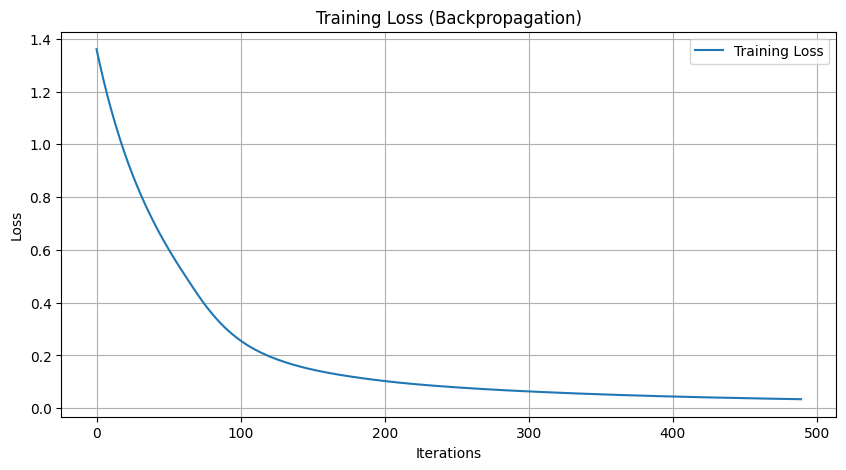

Interpretation:
- Decreasing loss: Model is learning
- Converged when loss stabilizes
- Final loss: 0.0341


In [18]:
# MLPClassifier stores loss curve during training
if hasattr(model, 'loss_curve_'):
    plt.figure(figsize=(10, 5))
    plt.plot(model.loss_curve_, label='Training Loss')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.title('Training Loss (Backpropagation)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    print("Interpretation:")
    print("- Decreasing loss: Model is learning")
    print("- Converged when loss stabilizes")
    print(f"- Final loss: {model.loss_curve_[-1]:.4f}")
else:
    print("No loss curve available (model may not have converged)")